<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Logistic-Regression/02_Breast_Cancer_using_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer #dataset
from sklearn.model_selection import train_test_split #for splitting the data into train and test
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Model Evaluation

In [56]:
# Load the breast cancer dataset
data = load_breast_cancer()  # Dataset stored in variabel data.
X = data.data  #Input Variables
Y = data.target  #Output Variables
print(data.keys())  # it lists all sections inside the dataset
print(X.shape) # Size of the features in format (no. Of rows, no. Of columns)
print(Y.shape) # Size of the target values
print(data.target_names) # names if the target i.e malignant, benign
df = pd.DataFrame(X, columns = data.feature_names)
df['target'] = Y
df.head()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
(569, 30)
(569,)
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [57]:
# Split dataset into train and test sets
X_train, X_test, Y_train, Y_test = train_test = train_test_split(X, Y, test_size=0.2, random_state = 42)

In [58]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #"fit" calculates the mean and standard deviation of the dataset , #"transform" applies the scaling: (x-mean) / std
X_test_scaled = scaler.transform(X_test)

In [59]:
# Train Logistic Regression Model
model = LogisticRegression(penalty = 'l2', C=10, solver= 'lbfgs', max_iter = 5000) #C is inverse of regularization strength
# 'lbfgs' is algorithm used for optimization
model.fit(X_train_scaled, Y_train)

LogisticRegression(C=10, max_iter=5000)

In [60]:
# Make Predictions
Y_pred = model.predict(X_test_scaled) # Predict class labels (0 or 1) for the test set
Y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Predict probabilities for class 1(malignant)
# Probability of class 1(malignant)

# 0 = Benign , 1 = Malignant

In [61]:
#Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {accuracy*100: .2f} %\n")
conf_matrix = confusion_matrix(Y_test, Y_pred)
print(f"Confusion Matrix: {confusion_matrix(Y_test, Y_pred)}%\n") #Shows True Positives, True Negatives, False Positives, False Negatives
print(f"Classification Report: {classification_report(Y_test, Y_pred)}") #Shows pecision, recall, f1-score for each class

Accuracy:  97.37 %

Confusion Matrix: [[42  1]
 [ 2 69]]%

Classification Report:               precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



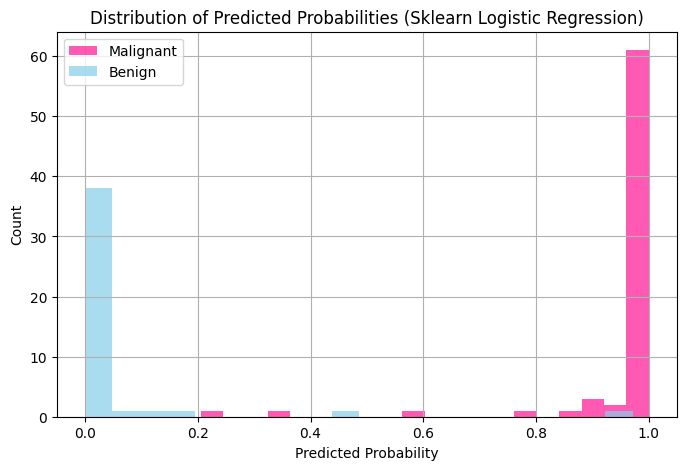

In [62]:
# Plotting a Histogram (It tells how confident the model is.)
plt.figure(figsize = (8, 5)) # Size of the graph
plt.hist(Y_pred_proba[Y_test==1], bins = 20, alpha = 0.7, label='Malignant', color = 'deeppink')
plt.hist(Y_pred_proba[Y_test==0], bins = 20, alpha = 0.7, label='Benign', color = 'skyblue')
#'bins' divides the range of probabilities(0 and 1) into 20 intervals
#'alpha' controls transparency of bars
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribution of Predicted Probabilities (Sklearn Logistic Regression)')
plt.legend()
plt.grid(True) #draws the grids behind the plot
plt.show()